In [3]:
import pandas as pd
from connec_functions import GDB
import requests

from accessibility import check_endpoint

### Interoperability Assessment of ICOS Carbon SPARQL Endpoint

### Endpoint

In [1]:
# The given endpoint is the human-facing (UI) SPARQL Endpoint
browser_endpoint = "https://meta.icos-cp.eu/sparqlclient/?type=CSV"

In [ ]:
# The machine-facing (API) SPARQL Endpoint is:
cli_endpoint = "https://meta.icos-cp.eu/sparql"
gdb = GDB(cli_endpoint, "endpoint_queries")

#gdb = GDB(cli_endpoint, "endpoint_queries")
#gdb.execute_to_df("general.sparql")

HTTPError: HTTP Error 501: Not Implemented

##### Table Of Content

- [Understanding the SPARQL endpoint structure](#understanding-sparql-endopint-structure)
- [Technical interoperability](#technical-interoperability)
    - SPARQL protocol support ~ version and supported features
    - Content negotiation and format support 
    - Endpoint connectivity and performance (~ includes endpoint availability, connectivity, perofrmance and timeout handling) 
- [Semantic interoperability](#semantic-interoperability)
    - Use of standard vocabularies
    - Ontology usage and semantic alignment 
    - Use of linked data principles (URIs)
    - Multilingual support
    - (Inference and reasoning support)

### Understanding the SPARQL endpoint structure
*Involves getting to understand the underlying RDF graph structure*

In [7]:
# Test browser/UI endpoint vs. CLI/API endpoint
params = {
    "query": "SELECT * WHERE { ?s ?p ?o } LIMIT 1"
}
headers = {
    "Accept": "application/sparql-results+json"
}

resp_ui = requests.get(browser_endpoint, params=params, headers=headers)
print("UI endpoint status:", resp_ui.status_code)

resp_api = requests.get(cli_endpoint, params=params, headers=headers)
print("API endpoint status:", resp_api.status_code)

UI endpoint status: 406
API endpoint status: 200


In [8]:
# general exploration
gdb.execute_to_df("general.sparql")

NameError: name 'gdb' is not defined

## Note on 'granularity' ....

granularity goes to file level 'cpmeta:DataObject's represent a.o. for example csv files , of which the structure/content is described in metadata, but to which a link to obtain the file is not available
((example DataObject: <https://meta.fieldsites.se/objects/8uNF3qqyXBclYG7mBFj9Adn4>))

preliminary notes on exploration of underlying graph structure:
- sparql endpoint returns both data and ontology + also includes various representations of data (e.g. dcat representation and )

- SPARQL endpoints includes 4 owl:Ontology
    - `<http://meta.icos-cp.eu/resources/cpmeta/>`  ~ simply import the next one...
    - `<http://meta.icos-cp.eu/ontologies/cpmeta/>`
    - `<http://meta.icos-cp.eu/ontologies/otcmeta/>`
    - `<http://meta.icos-cp.eu/ontologies/stationentry/>`
- ontology itself not available? 
    - http://meta.icos-cp.eu/ontologies/stationentry/ results in download of `stationsschema.rdf` which doesn't return valid RDF
    - http://meta.icos-cp.eu/ontologies/otcmeta/ results in download of `otcschema.rdf` which also doesn't return valid RDF
    - http://meta.icos-cp.eu/ontologies/cpmeta/ results in download of `instanceschema.rdf` which also doesn't return valid RDF
    - ontology terms are available and described on html document

- (cpmeta:hasKeywords) keywords are currently stored as string (represent list of keywords); these could be stored as array of standard terms...
- ValueFormat classes do not reference already existing value formats (e.g. float32, iso8601date, ....)

- standard terms are defined as owl:NamedIndividual, rather than as a skos:Concept like in argo ontology...

- there appear to 2 representations of stations:  
    - <http://meta.icos-cp.eu/resources/stations/ES_SE-Svb>	
    - <https://meta.fieldsites.se/resources/stations/Svartberget>
both are described in RDF  
but do not appear to be linked to each other 

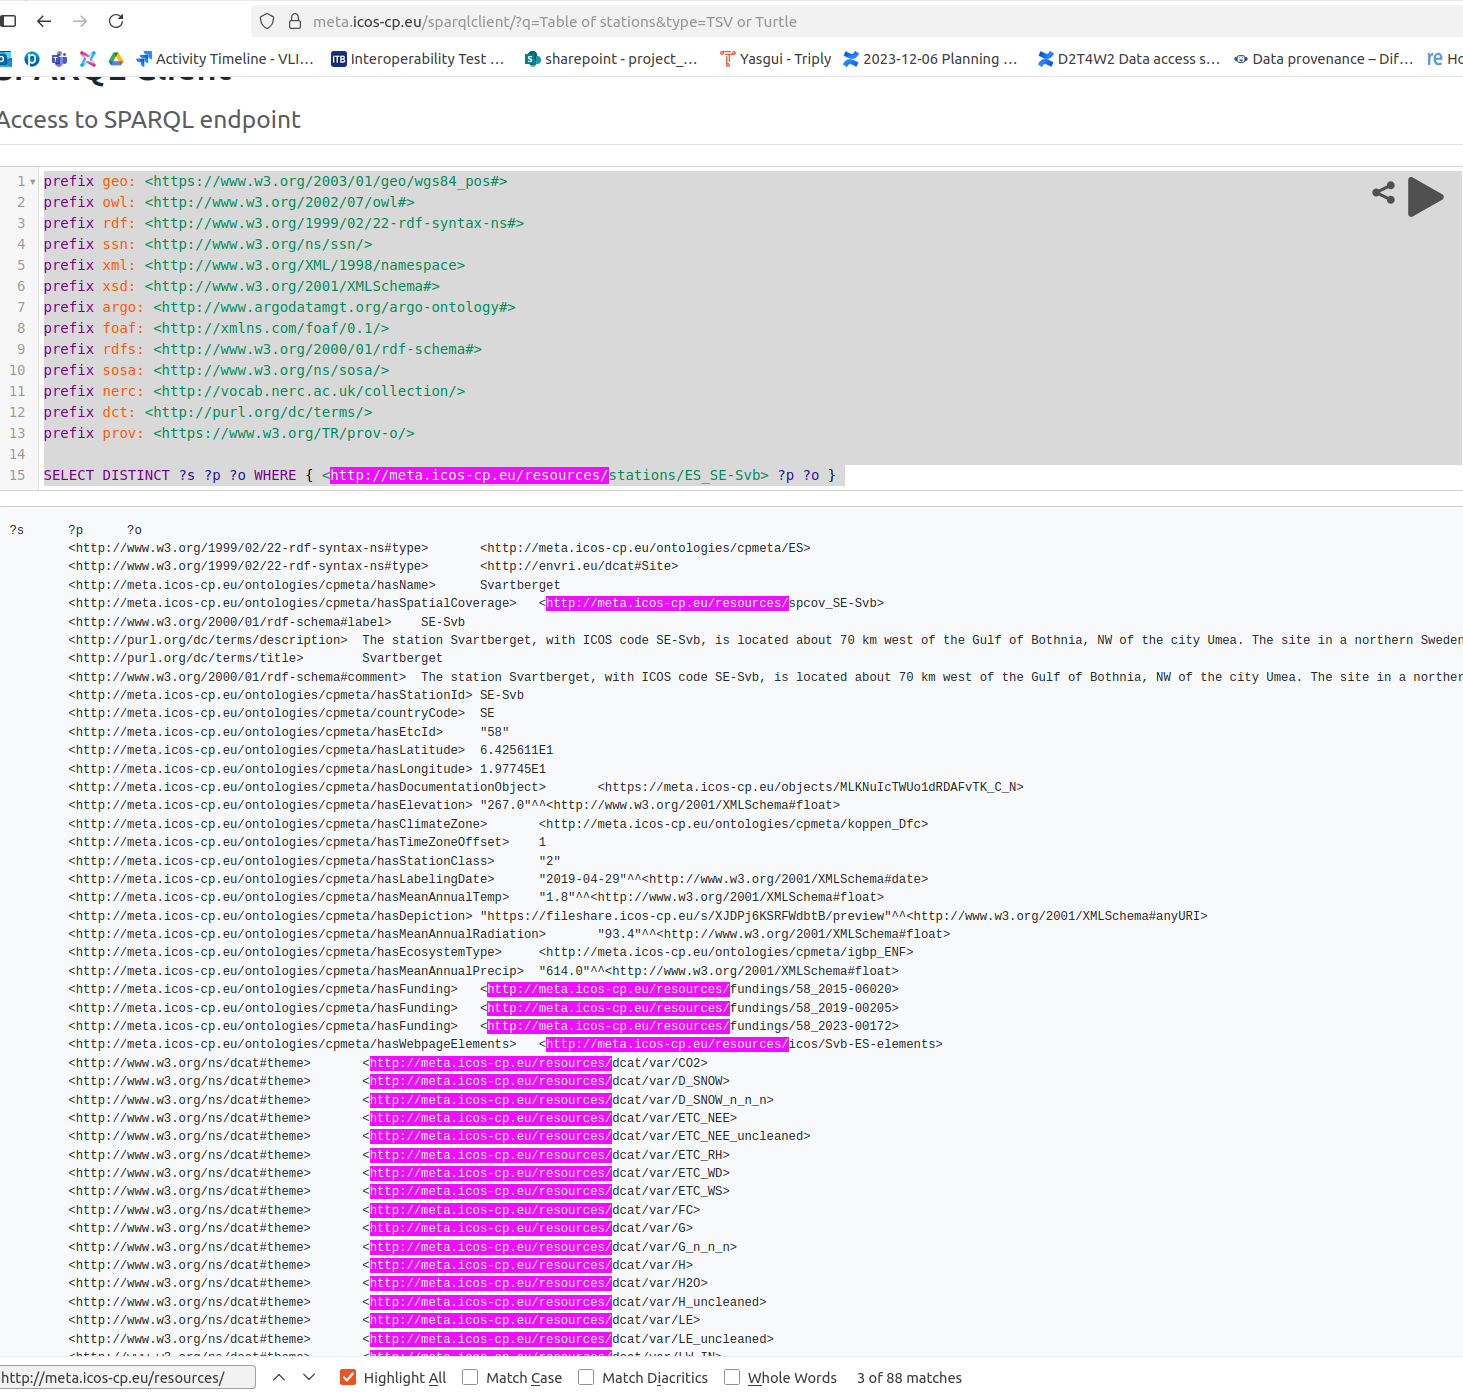
--> note the reference to <http://envri.eu/dcat#Site>  
there is also further along in the results <http://inspire.ec.europa.eu/metadata-codelist/TopicCategory/environment> 



side note:
what is the difference between <http://meta.icos-cp.eu/ontologies/cpmeta/hasResponsibleOrganization> and <https://meta.fieldsites.se/ontologies/sites/hasResponsibleOrganization> ?

(they both occur in the result of following query:
SELECT DISTINCT ?predicate ?object WHERE { <https://meta.fieldsites.se/resources/stations/Svartberget> ?predicate ?object } )

**Queries executed to obtain view on self-declared classes & properties in data model of ICOS data**

To obtain a view on the data model used to offer ICOS data as LD through the ICOS sparql endpoint, a number of sparql queries were executed and the results were then visualized as diagrams making use of Graphoo, which is a graphical framework for OWL ontologies ([specification](https://essepuntato.it/graffoo/)).

The first query returns classes and properties used in the stationentry ontology
```
SELECT DISTINCT ?s ?p ?o
FROM <http://meta.icos-cp.eu/ontologies/stationentry/>
WHERE {
	?s ?p ?o .
}
LIMIT 1000
```

![Local Image](images/ICOS_CP_datamodel.drawio.png)


The second query return classes and properties used in the cpmeta ontology
```
SELECT DISTINCT ?s ?p ?o 
FROM <http://meta.icos-cp.eu/ontologies/cpmeta/>
WHERE {
	?s ?p ?o .
}
LIMIT 2000
```

(this is a preliminary diagram of data model diagram (not all classes/predicates yet included))

![Local Image](images/ICOS_CP_datamodel2.drawio.png)


**A few instance examples:**

```
SELECT DISTINCT ?s ?p ?o
FROM <http://meta.icos-cp.eu/resources/stationentry/>
#FROM <http://meta.icos-cp.eu/ontologies/stationentry/>
#FROM <http://meta.icos-cp.eu/resources/icos/>
WHERE {
	<http://meta.icos-cp.eu/ontologies/stationentry/ES/IT-Noe> ?p ?o .
}
LIMIT 1000
```

![Local Image](images/ICOS_CP_datamodel-instance%20example.drawio.png)



```
SELECT DISTINCT ?p ?o
FROM <http://meta.icos-cp.eu/resources/stationentry/>
#FROM <http://meta.icos-cp.eu/ontologies/stationentry/>
#FROM <http://meta.icos-cp.eu/resources/icos/>
WHERE {
	<http://meta.icos-cp.eu/ontologies/stationentry/PI/spano@uniss.it> ?p ?o .
}
LIMIT 1000
```

![Local Image](images/ICOS_CP_datamodel-instance%20example%202.drawio.png)


Properties within different ICOS domains (terrestrial, marine & ocean, atmospheric)

### Technical interoperability

#### SPARQL protocol support 
*Involves checking the version and supported features*

To fully comply with the SPARQL 1.1 Protocol (per [W3C spec](https://www.w3.org/TR/sparql11-protocol/)), an endpoint must support specific HTTP request types (methods) and media types for two main functionalities:

1. SPARQL Query (Read operations)

(Support for SELECT, ASK, DESCRIBE, CONSTRUCT)
| HTTP Method | Content-Type                        | Required                             |
| ----------- | ----------------------------------- | ------------------------------------ |
| **GET**     | N/A (query via URL)                 | ✔️ Yes                               |
| **POST**    | `application/x-www-form-urlencoded` | ✔️ Yes                               |
| **POST**    | `application/sparql-query`          | ⚠️ Optional, but strongly encouraged |


- Accept headers for content negotiation should also be supported:
    - application/sparql-results+json
    - application/sparql-results+xml
    - application/rdf+xml, text/turtle, etc. for CONSTRUCT/DESCRIBE


2. SPARQL Update (Write operations)

(Support for INSERT, DELETE, LOAD, etc.)
| HTTP Method | Content-Type                | Required |
| ----------- | --------------------------- | -------- |
| **POST**    | `application/sparql-update` | ✔️ Yes   |


- Only POST is allowed for SPARQL Update — GET is not valid.
- Responses are typically empty or with status 204 No Content.


3. Content Negotiation

The endpoint must respond appropriately based on the Accept header:
- For SELECT, ASK: support application/sparql-results+json, ...+xml
- For CONSTRUCT, DESCRIBE: support at least one RDF serialization:
    - application/rdf+xml, text/turtle, application/ld+json, etc.


4. Response Codes and Compliance

- Return 200 OK for valid queries.
- Return 400 Bad Request or 500 Internal Server Error for syntax/logic errors.
- May support OPTIONS for preflight (CORS-related, not required by SPARQL spec).



Summary Table:
| Function            | HTTP Method | Content-Type                        | Required                        |
| ------------------- | ----------- | ----------------------------------- | ------------------------------- |
| Query (GET)         | `GET`       | URL parameter `?query=`             | ✔️                              |
| Query (POST)        | `POST`      | `application/x-www-form-urlencoded` | ✔️                              |
| Query (POST raw)    | `POST`      | `application/sparql-query`          | ⚠️ Optional                     |
| Update              | `POST`      | `application/sparql-update`         | ✔️                              |
| Content Negotiation | `GET/POST`  | `Accept` header for result formats  | ✔️                              |
| Preflight/CORS      | `OPTIONS`   | N/A                                 | ❌ Not part of spec, but helpful |



In [8]:
def test_read_operations(endpoint, read_type="SELECT"):
    print(f"📥 Testing SPARQL 1.1 READ Operation: {read_type}\n")

    queries = {
        "SELECT": "SELECT * WHERE { ?s ?p ?o } LIMIT 1",
        "ASK": "ASK { ?s ?p ?o }",
        "CONSTRUCT": "CONSTRUCT { <http://example.org/res> ?p ?o } WHERE { <http://example.org/res> ?p ?o }",
        "DESCRIBE": "DESCRIBE <http://example.org/res>"
    }

    if read_type not in queries:
        print(f"❌ Unsupported query type: '{read_type}'. Choose from: {list(queries.keys())}")
        return

    query = queries[read_type]

    # Adjust Accept header based on type of expected result
    accept = (
        "application/sparql-results+json"
        if read_type in ["SELECT", "ASK"]
        else "text/turtle"
    )

    try:
        r_get = requests.get(endpoint, params={"query": query}, headers={"Accept": accept})
        print("GET:", r_get.status_code, r_get.headers.get("Content-Type"))
    except Exception as e:
        print("GET Error:", e)

    try:
        r_post_form = requests.post(endpoint, data={"query": query}, headers={"Accept": accept})
        print("POST form:", r_post_form.status_code, r_post_form.headers.get("Content-Type"))
    except Exception as e:
        print("POST form Error:", e)

    try:
        r_post_raw = requests.post(endpoint, data=query, headers={
            "Content-Type": "application/sparql-query",
            "Accept": accept
        })
        print("POST raw:", r_post_raw.status_code, r_post_raw.headers.get("Content-Type"))
    except Exception as e:
        print("POST raw Error:", e)

In [9]:
test_read_operations(cli_endpoint, "SELECT")

📥 Testing SPARQL 1.1 READ Operation: SELECT

GET: 200 application/sparql-results+json; charset=UTF-8
POST form: 200 application/sparql-results+json; charset=UTF-8
POST raw: 200 application/sparql-results+json; charset=UTF-8


In [10]:
test_read_operations(cli_endpoint, "ASK")

📥 Testing SPARQL 1.1 READ Operation: ASK

GET: 501 text/plain; charset=UTF-8
POST form: 501 text/plain; charset=UTF-8
POST raw: 501 text/plain; charset=UTF-8


In [11]:
test_read_operations(cli_endpoint, "CONSTRUCT")

📥 Testing SPARQL 1.1 READ Operation: CONSTRUCT

GET: 200 text/turtle; charset=UTF-8
POST form: 200 text/turtle; charset=UTF-8
POST raw: 200 text/turtle; charset=UTF-8


In [12]:
test_read_operations(cli_endpoint, "DESCRIBE")

📥 Testing SPARQL 1.1 READ Operation: DESCRIBE

GET: 200 text/turtle; charset=UTF-8
POST form: 200 text/turtle; charset=UTF-8
POST raw: 200 text/turtle; charset=UTF-8


In [13]:
def test_write_operations(endpoint_url, operation_type="INSERT DATA"):
    updates = {
        "INSERT DATA": """
            INSERT DATA {
                <http://example.org/test> <http://example.org/prop> "test_insert" .
            }
        """,
        "DELETE DATA": """
            DELETE DATA {
                <http://example.org/test> <http://example.org/prop> "test_insert" .
            }
        """,
        "DELETE/INSERT": """
            DELETE {
                <http://example.org/test> <http://example.org/prop> "old_value" .
            }
            INSERT {
                <http://example.org/test> <http://example.org/prop> "new_value" .
            }
            WHERE {
                OPTIONAL { <http://example.org/test> <http://example.org/prop> "old_value" }
            }
        """,
        "CLEAR DEFAULT": """
            CLEAR DEFAULT
        """
    }

    headers = {
        "Content-Type": "application/sparql-update"
    }

    print(f"📝 Testing SPARQL 1.1 Write Operation: {operation_type}\n")

    if operation_type not in updates:
        print(f"❌ Unsupported operation type: '{operation_type}'. Choose from: {list(updates.keys())}")
        return

    update_query = updates[operation_type]

    try:
        response = requests.post(endpoint_url, data=update_query.strip(), headers=headers, timeout=10)
        print(f"Status: {response.status_code} | Content-Type: {response.headers.get('Content-Type')}")
        if response.status_code >= 400:
            print("⚠️  Error response:", response.text[:200])
    except Exception as e:
        print("❌ Request failed:", e)


In [14]:
test_write_operations(cli_endpoint, "INSERT DATA")

📝 Testing SPARQL 1.1 Write Operation: INSERT DATA

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "insert" "INSERT "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [15]:
test_write_operations(cli_endpoint, "DELETE DATA")

📝 Testing SPARQL 1.1 Write Operation: DELETE DATA

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "delete" "DELETE "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [16]:
test_write_operations(cli_endpoint, "DELETE/INSERT")

📝 Testing SPARQL 1.1 Write Operation: DELETE/INSERT

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "delete" "DELETE "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [17]:
test_write_operations(cli_endpoint, "CLEAR DEFAULT")

📝 Testing SPARQL 1.1 Write Operation: CLEAR DEFAULT

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "clear" "CLEAR "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


#### Content negotiation and format support 

both human-faced and machine-faced SPARQL endpoint were consulted for the assessment of this part

In [18]:
def get_header_info(endpoint):
    response = requests.get(endpoint)
    server_headers = response.headers

    return {
        # General protocol and status checks
        "General protocol and status checks" : 
            {
            "HTTP/HTTPS Protocol": endpoint.startswith("http"),
            "Status Code 200 OK": response.status_code == 200,
            },
        # Content negotiation
        "Content negotiation" : 
            {
            "MIME Type Present": "Content-Type" in server_headers,
            "MIME Type": server_headers.get("Content-Type"),
            "Content Negotiation Support": "Vary" in server_headers or "Accept" in server_headers,
            "Vary": server_headers.get("Vary"),                         # response may change depending on 'Accept-Encoding'
            "Accept-Ranges": server_headers.get("Accept-Ranges"),       # support partial content requests (e.g., 'bytes')
            },
        # Content negotiation related headers
        "Content negotiation related headers" : 
            { 
            "Content-Length": server_headers.get("Content-Length"),             # total size of the file, if specified
            "Content-Disposition": server_headers.get("Content-Disposition"),   # tells if file is inline or attachment
            "Content-Encoding": server_headers.get("Content-Encoding"),         # compression format (e.g., gzip)
            "Accept": server_headers.get("Accept"),                             # what media types the client accepts (rare in response)
            "Accept-Encoding": server_headers.get("Accept-Encoding"),           # what compression formats the client accepts (rare in response)
            },
        # Caching-related headers
        "Caching-related headers" : 
            {
            "Cache-Control": server_headers.get("Cache-Control"),       # caching policy (e.g., no-cache, max-age)
            "ETag": server_headers.get("ETag"),                         # version identifier for the file, useful for caching and validation
            }
    }

In [19]:
get_header_info(browser_endpoint)

{'General protocol and status checks': {'HTTP/HTTPS Protocol': True,
  'Status Code 200 OK': True},
 'Content negotiation': {'MIME Type Present': True,
  'MIME Type': 'text/html; charset=UTF-8',
  'Content Negotiation Support': False,
  'Vary': None,
  'Accept-Ranges': None},
 'Content negotiation related headers': {'Content-Length': None,
  'Content-Disposition': None,
  'Content-Encoding': 'gzip',
  'Accept': None,
  'Accept-Encoding': None},
 'Caching-related headers': {'Cache-Control': None, 'ETag': None}}

In [20]:
get_header_info(cli_endpoint)

{'General protocol and status checks': {'HTTP/HTTPS Protocol': True,
  'Status Code 200 OK': False},
 'Content negotiation': {'MIME Type Present': True,
  'MIME Type': 'text/plain; charset=UTF-8',
  'Content Negotiation Support': False,
  'Vary': None,
  'Accept-Ranges': None},
 'Content negotiation related headers': {'Content-Length': '314',
  'Content-Disposition': None,
  'Content-Encoding': None,
  'Accept': None,
  'Accept-Encoding': None},
 'Caching-related headers': {'Cache-Control': None, 'ETag': None}}

cors headers specifiek --> in get request origin header zetten  
    `Origin: http://test.vliz.be `

verwachte respons:  
access-control-allow-origin: * OF http://test.vliz.be

check ook 'http monitoring tools' in google

In [21]:
# assess formats returned by cli_endpoint
query = "CONSTRUCT { ?s ?p ?o } WHERE { ?s ?p ?o } LIMIT 1"
formats = {
    "SPARQL JSON": "application/sparql-results+json",
    "SPARQL XML": "application/sparql-results+xml",
    "RDF/XML": "application/rdf+xml",
    "Turtle": "text/turtle",
    "JSON-LD": "application/ld+json"
}

for name, mime in formats.items():
    headers = {"Accept": mime}
    params = {"query": query}
    
    try:
        r = requests.get(cli_endpoint, headers=headers, params=params, timeout=10)
        status = r.status_code
        ctype = r.headers.get("Content-Type", "")
        print(f"{name:15} → {status} | {ctype}")
    except Exception as e:
        print(f"{name:15} → ERROR: {e}")

SPARQL JSON     → 406 | text/plain; charset=UTF-8
SPARQL XML      → 406 | text/plain; charset=UTF-8
RDF/XML         → 200 | application/rdf+xml; charset=UTF-8
Turtle          → 200 | text/turtle; charset=UTF-8
JSON-LD         → 406 | text/plain; charset=UTF-8


#### Endpoint connectivity and performance 
*Includes checking endpoint availability, connectivity, perofrmance and timeout handling*

In [ ]:
if check_endpoint(sparql_endpoint_url):
    print("The endpoint is machine-accessible.")
else:
    print("The endpoint is not machine-accessible.")

Findings

SPARQL protocol support
- ...

Content negotiation and format support
- ...

Endpoint connectivity and performance
- no timeout issues here


- sparql endpoint only queryable though browser interface, trying through code returns "501: Not Implemented"
- general queries take long time to run
- there is a set per-minute query quota

### Semantic interoperability

#### Use of standard vocabularies

#### Ontology usage and semantic alignment 
*Includes 'ontology and vocabulary compatibility', 'cross-dataset semantic linking', 'consistency of semantics'*

#### Use of linked data principles (URIs)

#### Multilingual support

Findings:

Use of standard vocabularies
- ...

Ontology usage and semantic alignment
- ...

Use of linked data principles (URIs)
- ...

Multilingual support
- ...

- RDF ~ data standardized
- Use of internally defined ontologies
  - requires knowledge on the location of the ontologies / vocabularies and getting to know them ~~ less machine interoperable
  - sidenote: prefixes not registered on prefix.cc ~ would increase findability (+ also registering in ontology catalogues/archives)
- Also use of known & common ontologies such as dcat (see example SPARQL query "DCAT metadata demo")  
*(note: to facilitate integration of data between different sources it would be better is data is described using common & well known ontologies/vocabularies + potential extension to those if domain specific information cannot be described by those ontologies)*

- use of known & trusted standard terms for mediaType and license (e.g. MIME-Types using iana.org, licenses using CC-urls)
- data granularity: file level
  - data files are accessible with dcat:downloadUrl within a dcat:distribution (data points themselves are not described in RDF)